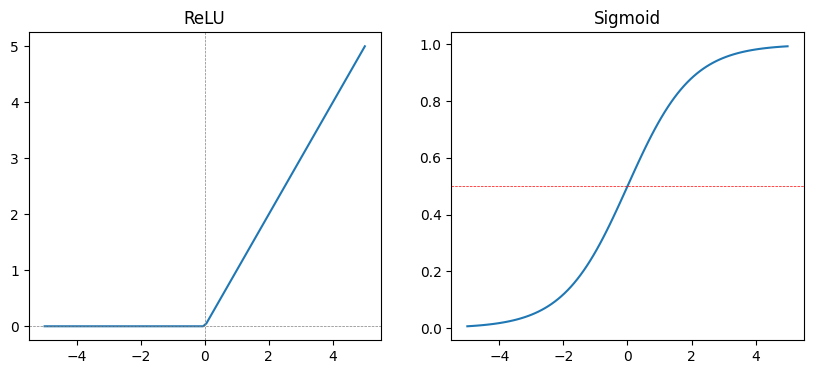

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ReLUを実装する
def relu(x):
    return np.maximum(0, x)

# シグモイドも再確認
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-5, 5, 100)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(x, relu(x))
plt.title("ReLU")
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)

plt.subplot(1, 2, 2)
plt.plot(x, sigmoid(x))
plt.title("Sigmoid")
plt.axhline(y=0.5, color='r', linestyle='--', linewidth=0.5)

plt.show()

In [4]:
# シンプルな2層ニューラルネットを実装する
# 入力2次元 → 隠れ層3ユニット → 出力1次元

np.random.seed(42)

# 重みとバイアスをランダムで初期化する
W1 = np.random.randn(2, 3)  # 入力2 → 隠れ層3
b1 = np.zeros(3)
W2 = np.random.randn(3, 1)  # 隠れ層3 → 出力1
b2 = np.zeros(1)

print("W1の形:", W1.shape)
print("W2の形:", W2.shape)
print("\nW1:\n", W1.round(3))


print(f"b1: {b1}")
print(f"b2: {b2}")

W1の形: (2, 3)
W2の形: (3, 1)

W1:
 [[ 0.497 -0.138  0.648]
 [ 1.523 -0.234 -0.234]]
b1: [0. 0. 0.]
b2: [0.]


In [5]:
# 入力データ（x1=1.0, x2=2.0 の場合）
x = np.array([1.0, 2.0])

# 隠れ層の計算
z1 = x @ W1 + b1   # 線形変換
h1 = relu(z1)      # 活性化関数

# 出力層の計算
z2 = h1 @ W2 + b2  # 線形変換
y = sigmoid(z2)    # 活性化関数（0〜1の確率に変換）

print("入力:", x)
print("隠れ層（活性化前）:", z1.round(3))
print("隠れ層（活性化後）:", h1.round(3))
print("出力:", y.round(3))

入力: [1. 2.]
隠れ層（活性化前）: [ 3.543 -0.607  0.179]
隠れ層（活性化後）: [3.543 0.    0.179]
出力: [0.996]


In [6]:
# 正解ラベル（この入力はポジティブ=1とする）
y_true = np.array([1.0])

# 予測値は先ほどの出力
y_pred = y  # 0.996

# 損失関数（二乗誤差）
loss = np.mean((y_true - y_pred) ** 2)
print("予測値:", y_pred.round(4))
print("正解:", y_true)
print("損失:", loss.round(6))

予測値: [0.996]
正解: [1.]
損失: 1.6e-05


In [7]:
pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 7.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 4.4 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 13.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 23.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 15.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 8.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 29.0 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 19.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 14.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━

In [8]:
import torch
import torch.nn as nn

# Numpyの配列をPyTorchのテンソルに変換suru
x = torch.tensor([1.0, 2.0])
y_true = torch.tensor([1.0])

print("xの型", type(x))
print("xの形", x.shape)
print("x:", x)

xの型 <class 'torch.Tensor'>
xの形 torch.Size([2])
x: tensor([1., 2.])


In [10]:
# requires_grad=True で「この変数の勾配を計算してね」と指示する
W1 = torch.randn(2, 3, requires_grad=True)
b1 = torch.zeros(3, requires_grad=True)
W2 = torch.randn(3, 1, requires_grad=True)
b2 = torch.zeros(1, requires_grad=True)

x = torch.tensor([1.0, 2.0])
y_true = torch.tensor([1.0])

# 順伝播
z1 = x @ W1 + b1
h1 = torch.relu(z1)
z2 = h1 @ W2 + b2
y_pred = torch.sigmoid(z2)

# 損失計算
loss = torch.mean((y_true - y_pred) ** 2)
print("損失:", loss.item())

# 逆伝播（勾配を自動計算）
loss.backward()

# W1の勾配を確認
print("\nW1の勾配:\n", W1.grad)

損失: 0.3220555782318115

W1の勾配:
 tensor([[0.0000, 0.0000, 0.0668],
        [0.0000, 0.0000, 0.1336]])


In [11]:
# 学習率
lr = 0.01

# 勾配を使って重みを更新する
with torch.no_grad():  # 更新時は勾配計算を止める
    W1 -= lr * W1.grad
    b1 -= lr * b1.grad
    W2 -= lr * W2.grad
    b2 -= lr * b2.grad

# 勾配をリセット（次の学習のために）
W1.grad.zero_()
b1.grad.zero_()
W2.grad.zero_()
b2.grad.zero_()

# 更新後の損失を確認
z1 = x @ W1 + b1
h1 = torch.relu(z1)
z2 = h1 @ W2 + b2
y_pred = torch.sigmoid(z2)
loss = torch.mean((y_true - y_pred) ** 2)
print("更新後の損失:", loss.item())

更新後の損失: 0.32002195715904236


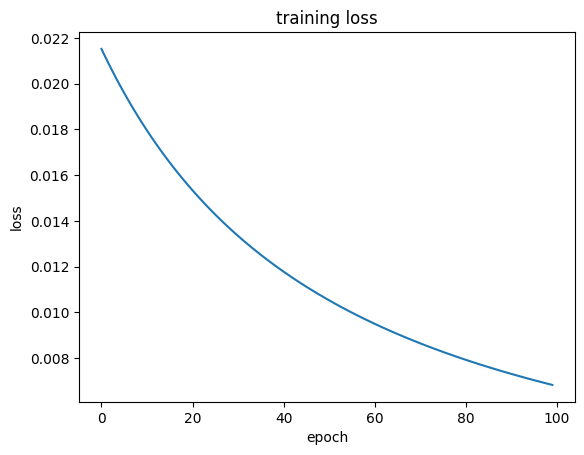

初期損失: 0.021520810201764107
最終損失: 0.006823330651968718


In [12]:
# 重みを最初からリセット
torch.manual_seed(42)
W1 = torch.randn(2, 3, requires_grad=True)
b1 = torch.zeros(3, requires_grad=True)
W2 = torch.randn(3, 1, requires_grad=True)
b2 = torch.zeros(1, requires_grad=True)

lr = 0.01
losses = []

for i in range(100):
    # 順伝播
    z1 = x @ W1 + b1
    h1 = torch.relu(z1)
    z2 = h1 @ W2 + b2
    y_pred = torch.sigmoid(z2)

    # 損失計算
    loss = torch.mean((y_true - y_pred) ** 2)
    losses.append(loss.item())

    # 逆伝播
    W1.grad = None  # zero_()の代わりにNoneでリセット
    b1.grad = None
    W2.grad = None
    b2.grad = None
    loss.backward()

    # 重みを更新
    with torch.no_grad():
        W1 -= lr * W1.grad
        b1 -= lr * b1.grad
        W2 -= lr * W2.grad
        b2 -= lr * b2.grad

# 損失の推移をグラフで確認
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("training loss")
plt.show()

print("初期損失:", losses[0])
print("最終損失:", losses[-1])